
# EE 467 Final Project  
## Botnet Detection Using Machine Learning  

**Team Members:** Ethan Le, Dhruv Naik  

Our project focuses on botnet detection by analyzing network traffic patterns using machine learning. Botnets are a significant cybersecurity threat, enabling large-scale distributed denial-of-service (DDoS) attacks, spam campaigns, and data exfiltration. The objective of this project is to detect malicious botnet traffic within network flow data while minimizing false positives, which is critical in operational cybersecurity settings.

In this project we will:
1. Import and Configure all libraries
2. Load Data into a dataframe
3. Process Labels
4. Handle Feature Engineering and Leakage Control
5. Split Training and Testing Data
6. Handle Scaling and Class Imbalance
7. Run a Logistic Regression Baseline
8. Test Random Forest and XGBoost Tree-Based Models
9. Test an Autoencoder model using Anomaly Detection
10. Cross Scenario Evaluate
11. Try training on a different scenario



## 1. Imports and Configuration

This section loads required libraries and sets random seeds for reproducibility.


In [1]:

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    classification_report
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight

import xgboost as xgb

import torch
import torch.nn as nn
from torch.nn import functional as f
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import AdamW
from itertools import chain

from final_util import timeit, recall_at_fixed_fpr, select_threshold_at_fpr, evaluate_model_performance, train_data, evaluate_and_plot_multiple_scenarios


RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)



## 2. Data Loading

We load CTU-13 NetFlow .binetflow files for selected scenarios.
They can be treated like CSV files
In this project we will train on scenerio 8, evaluating to find the best model.
Then we will cross-evaluate on scenerio 11, to ensure the model holds accross datasets. 

This is done by loading a .binetflow file into a DataFramea and cleaning the column names by stripping whitespace. Additionally it filters out rows labeled as 'Background' to ensure that only definitive 'Botnet' and 'Normal' traffic is retained for analysis. This is done to remove noise from the training dataset. 

For our Project we are loading in scenario 8 due to it having the most available data. It's most destinctive botnet characteriststic is Port Scan. 


In [2]:
# --- Section 2: Data Loading & CSV Conversion ---
DATA_DIR = "./"  # Update this to your local path

# Name: load_and_clean_binetflow
# Description: Loads a .binetflow file, cleans whitespace from column names, 
#              and filters out 'Background' traffic to ensure clean labels.
def load_and_clean_binetflow(DATA_DIR, filename):

    path = os.path.join(DATA_DIR, filename)
    print(f"Loading {filename}...")
    
    # binetflow files are CSVs, we strip whitespace from headers
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()
    
    # Filter for only definitive labels: 'Botnet' or 'Normal'
    # This removes 'Background' flows which are unlabeled and can introduce noise
    initial_count = len(df)
    df = df[df['Label'].str.contains('Botnet|Normal', case=False, na=False)].copy()
    
    print(f"Filtered {initial_count - len(df)} background rows. {len(df)} rows remaining.")
    return df

# Load Scenario 8 (Murlo) data
scenario_8_raw = load_and_clean_binetflow(DATA_DIR, "capture20110816-3.binetflow")

Loading capture20110816-3.binetflow...
Filtered 2875281 background rows. 78949 rows remaining.



## 3. Label Processing (Binary Setup)

The Datafram has a 'Label' column that contains descriptive CTU-13 labels, instead we want a new 'binary_label' column. This function maps any label containing 'Botnet', 'C&C', or 'Malware' to 1 (indicating malicious activity), and all other labels to 0 (indicating normal traffic). 
This binary labeling is essential for training classification models that require a binary target variable.



In [3]:
# Name : process_labels
# Description: Processes the 'Label' column to create a binary label 'binary_label' 
#              where 1 indicates Botnet activity and 0 indicates Normal traffic.
def process_labels(df):
    df = df.copy()
    
    # CTU-13 labels often look like 'flow=From-Botnet-V1-TCP-HTTP-1'
    # We use string contains to capture all variations of malicious activity
    df['binary_label'] = df['Label'].apply(
        lambda x: 1 if any(s in str(x) for s in ['Botnet', 'C&C', 'Malware']) else 0
    )
    
    return df

# --- Verify Loading and Labeling ---

# Process the labels
processed_df = process_labels(scenario_8_raw)

# Display examples of both Normal (0) and Botnet (1) traffic
cols_to_show = ['StartTime', 'Dur', 'Proto', 'SrcAddr', 'DstAddr', 'Label', 'binary_label']

print("--- Normal Traffic Verification (Label 0) ---")
display(processed_df[processed_df['binary_label'] == 0][cols_to_show].head(3))

print("\n--- Botnet Traffic Verification (Label 1) ---")
display(processed_df[processed_df['binary_label'] == 1][cols_to_show].head(3))

--- Normal Traffic Verification (Label 0) ---


,StartTime,Dur,Proto,SrcAddr,DstAddr,Label,binary_label
166,2011/08/16 14:18:56.645840,0.000328,udp,147.32.84.170,147.32.80.9,flow=From-Normal-V49-Stribrek,0
167,2011/08/16 14:18:56.646714,0.000410,udp,147.32.84.170,147.32.80.9,flow=From-Normal-V49-Stribrek,0
168,2011/08/16 14:18:56.647854,0.017853,tcp,147.32.84.170,209.85.148.106,flow=From-Normal-V49-Stribrek,0



--- Botnet Traffic Verification (Label 1) ---


,StartTime,Dur,Proto,SrcAddr,DstAddr,Label,binary_label
923,2011/08/16 14:19:01.438016,1.000221,udp,147.32.84.165,147.32.80.9,flow=From-Botnet-V49-UDP-DNS,1
1103,2011/08/16 14:19:02.439762,500.002869,tcp,147.32.84.165,195.113.232.98,flow=From-Botnet-V49-TCP-Established-HTTP-Ad-40,1
8354,2011/08/16 14:20:00.257453,0.000218,udp,147.32.84.165,147.32.80.9,flow=From-Botnet-V49-UDP-DNS,1



## 4. Feature Engineering and Leakage Control

We drop columns that might give the model information to cheat, for example the model might train off the source and destination IPs, ports, or the original text label.

Then we take a DataFrame and performs feature engineering by creating new features based on existing ones. We would like rate-based features such as bytes per second and packets per second. The function  `feature_engineering()` handles the categorical 'Proto' column using one-hot encoding to obtain these features. 

Afterwards we want to drops leakage columns, and separates the target variable (y) from the feature matrix (X). `prepare_features()` returns the cleaned feature matrix and target vector for model training.

In [4]:
# Columns to drop to prevent data leakage
DROP_COLUMNS = [
    'Label',      # Original text label (we use binary_label now)
    'SrcAddr',    # Source IP
    'DstAddr',    # Destination IP
    'StartTime',  # Timestamp
    'State',      # Connection state (text)
    'Dir',        # Directionality (text)
    'Sport',      # Source Port (often too high-cardinality for basic models)
    'Dport',      # Destination Port 
    'sTos',       # Source Type of Service
    'dTos'        # Destination Type of Service
]

# Name: feature_engineering
# Description: Takes a DataFrame and creates rate-based features
# (bytes per second and packets per second) using one-hot encoding from the 'Proto' column.
def feature_engineering(df):
    df = df.copy()
    
    # Create rate-based features using CTU-13 column names
    # Adding a small epsilon (1e-6) prevents division by zero if duration is 0
    df['bytes_per_sec'] = df['TotBytes'] / (df['Dur'] + 1e-6)
    df['pkts_per_sec'] = df['TotPkts'] / (df['Dur'] + 1e-6)
    
    # Handle Categorical Text Data: The 'Proto' (Protocol) column
    # We use One-Hot Encoding to turn 'tcp', 'udp', 'icmp' into separate 1 or 0 columns
    if 'Proto' in df.columns:
        # Group rare protocols into an 'other' category to keep feature space small
        df['Proto'] = df['Proto'].apply(lambda x: x if x in ['tcp', 'udp', 'icmp'] else 'other')
        proto_dummies = pd.get_dummies(df['Proto'], prefix='proto', dtype=int)
        df = pd.concat([df, proto_dummies], axis=1)
        df = df.drop(columns=['Proto'])
        
    return df

# Name: prepare_features
# Description: This function takes a DataFrame, drops leakage columns, and separates the target variable (y) from the feature matrix (X). 
def prepare_features(df, DROP_COLUMNS=DROP_COLUMNS):
    """
    Strips leakage columns and separates the target variable (y) 
    from the feature matrix (X).
    """
    df_cleaned = df.drop(columns=DROP_COLUMNS, errors='ignore')
    
    X = df_cleaned.drop(columns=['binary_label'], errors='ignore')
    y = df_cleaned['binary_label']
    
    return X, y

# --- Execute Feature Engineering & Preparation ---

# Apply feature engineering
engineered_df = feature_engineering(processed_df)

# Prepare features
X, y = prepare_features(engineered_df, DROP_COLUMNS=DROP_COLUMNS)

# Verify the resulting feature matrix
print("--- Feature Matrix X (First 5 rows) ---")
display(X.head())

print("\n--- Target Vector y (First 5 rows) ---")
display(y.head())

print(f"\nFinal shape of X: {X.shape}")

--- Feature Matrix X (First 5 rows) ---


,Dur,TotPkts,TotBytes,SrcBytes,bytes_per_sec,pkts_per_sec,proto_icmp,proto_other,proto_tcp,proto_udp
166,0.000328,2,400,74,1.215805e+06,6079.027356,0,0,0,1
167,0.000410,2,400,74,9.732360e+05,4866.180049,0,0,0,1
168,0.017853,7,478,272,2.677271e+04,392.069004,0,0,1,0
197,0.016182,2,120,60,7.415189e+03,123.586480,0,0,1,0
198,0.016431,2,120,60,7.302824e+03,121.713729,0,0,1,0



--- Target Vector y (First 5 rows) ---


166    0
167    0
168    0
197    0
198    0
Name: binary_label, dtype: int64


Final shape of X: (78949, 10)



## 5. Train/Test Split Data

We want to Split Scenario 8 into 80% Training data and 20% Validation data. We use `stratify=y` to ensure both sets keep the same 90% Normal / 10% Botnet ratio. Leter on we can test on a future dataset from Scenario 11 to evaluate cross-scenario generalization.


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE # Uses the seed defined in Section 1
)

# Print the shapes to verify the split
print("--- Data Split Verification ---")
print(f"Total samples: {len(X)}")
print(f"Training features (X_train): {X_train.shape}")
print(f"Validation features (X_test): {X_test.shape}")

# Verify the stratification worked (ratios should match)
print("\nTraining Target Distribution:")
print(y_train.value_counts(normalize=True).map('{:.2%}'.format))

print("\nValidation Target Distribution:")
print(y_test.value_counts(normalize=True).map('{:.2%}'.format))

# Note for later: 
# To get X_test and y_test, you will load a second scenario (Scenario 11)
# run it through feature_engineering() and prepare_features(), 
# and use that entire matrix as your unseen test set!

--- Data Split Verification ---
Total samples: 78949
Training features (X_train): (63159, 10)
Validation features (X_test): (15790, 10)

Training Target Distribution:
binary_label
0    92.24%
1     7.76%
Name: proportion, dtype: str

Validation Target Distribution:
binary_label
0    92.24%
1     7.76%
Name: proportion, dtype: str



## 6. Scaling and Class Imbalance

Due to data imbalances and values, we need to standard scale the data so that the model does not overfit to one metric. We must do this for both the training and test data. Next, we need to adjust the class weights so that our model does not overfit to the normal traffic. Since our splits are 90% normal/10% botnet, a "dumb" classifier would simply guess normal. Adjusting the class weights gives more value to the botnet traffic.


In [6]:
# Initialize and fit the scaler ONLY on the training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Transform validation data using the SAME scaler
X_test_scaled = scaler.transform(X_test)

# Compute class weights to handle the 90/10 imbalance
classes = np.unique(y_train)
weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

# Create a dictionary to pass into Logistic Regression and Random Forest
class_weight_dict = dict(zip(classes, weights))

# Verification Printout
print("--- Scaling & Class Weights Verification ---")
# If scaling worked, the mean should be practically 0 and standard deviation 1
print(f"X_train_scaled Mean: {np.mean(X_train_scaled):.2f}")
print(f"X_train_scaled Std Dev: {np.std(X_train_scaled):.2f}")

print(f"\nComputed Class Weights:")
for cls, weight in class_weight_dict.items():
    label_name = "Botnet (1)" if cls == 1 else "Normal (0)"
    print(f"{label_name}: {weight:.4f}")

--- Scaling & Class Weights Verification ---
X_train_scaled Mean: -0.00
X_train_scaled Std Dev: 1.00

Computed Class Weights:
Normal (0): 0.5421
Botnet (1): 6.4422



## 7. Logistic Regression Baseline

Now we create and test the the logistic regression model on the training set. From this we can calculate and evaluate the 1% FPR metric and see how the model fairs against the testing set. We are using probabilities (predict_proba) instead of hard predicitions because we want to achieve a 1% FPR. These allow us to calculate the ROC-AUC, threshold at 1% FPR, and the recall at 1% FPR. These metric are:

ROC-AUC: overall ability to distinguish traffic. 0.5 = random, 1.0 = perfect.

Threshold at 1% FPR: at what probability threshold will 99% of normal traffic be classified as normal, and 1% be incorrectly classified. A threshold of 0.45 would mean 99% of normal traffic scored a probability under 0.45.

Recall at 1% FPR: at the 1% FPR threshold, what percentage of botnet traffic is correctly classified as botnet.


In [7]:
print("--- Training Logistic Regression Baseline ---")

# Initialize the model
# We pass in the class_weight_dict we calculated in Section 6
with timeit("Training logistic regression classifier"):
    log_model = LogisticRegression(
        class_weight=class_weight_dict,
        max_iter=1000,
        random_state=RANDOM_STATE 
    ).fit(X_train_scaled, y_train)

print("Training complete.")

# Predict probabilities on the validation set
val_probs = log_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate using custom metrics
# Find the specific probability threshold that limits False Positives to 1%
threshold_1_fpr = select_threshold_at_fpr(y_test, val_probs, target_fpr=0.01)

# Calculate metrics
val_roc_auc = roc_auc_score(y_test, val_probs)
val_recall_at_1_fpr = recall_at_fixed_fpr(y_test, val_probs, target_fpr=0.01)

# Print the results
print(f"\n--- Validation Results (Scenario 8) ---")
print(f"ROC-AUC Score: {val_roc_auc:.4f}")
print(f"Threshold for 1% FPR: {threshold_1_fpr:.4f}")
print(f"Recall @ 1% FPR: {val_recall_at_1_fpr:.2%}")

# Show full classification report using our strict threshold
val_preds_strict = (val_probs >= threshold_1_fpr).astype(int)
print("\nClassification Report (using strict 1% FPR threshold):")
print(classification_report(y_test, val_preds_strict, target_names=['Normal (0)', 'Botnet (1)']))

--- Training Logistic Regression Baseline ---
Training logistic regression classifier started...
Training logistic regression classifier completed. Elapsed time: 0.09s

Training complete.

--- Validation Results (Scenario 8) ---
ROC-AUC Score: 0.9470
Threshold for 1% FPR: 0.3784
Recall @ 1% FPR: 76.57%

Classification Report (using strict 1% FPR threshold):
              precision    recall  f1-score   support

  Normal (0)       0.98      0.99      0.99     14565
  Botnet (1)       0.90      0.77      0.83      1225

    accuracy                           0.98     15790
   macro avg       0.94      0.88      0.91     15790
weighted avg       0.97      0.98      0.97     15790




## 8. Tree-Based Models

In this section we implement two different Tree-Based Models.

- Random Forest: This builds 200 independent decision trees and has them vote. This repressents the bagging model
- XGBoost: This builds 300 trees in series where the new tree fixes the istakes of the previous tree. This is based on the Boosting model. 



In [8]:
print("--- 8.1 Training Random Forest ---")
# Initialize Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight=class_weight_dict, 
    random_state=RANDOM_STATE,
    n_jobs=-1 
)

rf_model.fit(X_train, y_train)
rf_probs = rf_model.predict_proba(X_test)[:, 1]

# Calculate custom metrics
rf_threshold = select_threshold_at_fpr(y_test, rf_probs, target_fpr=0.01)
rf_auc = roc_auc_score(y_test, rf_probs)
rf_recall = recall_at_fixed_fpr(y_test, rf_probs, target_fpr=0.01)

print(f"Random Forest ROC-AUC: {rf_auc:.4f}")
print(f"Random Forest Threshold for 1% FPR: {rf_threshold:.4f}")
print(f"Random Forest Recall @ 1% FPR: {rf_recall:.2%}\n")

# Generate Classification Report using the strict threshold
rf_preds_strict = (rf_probs >= rf_threshold).astype(int)
print("Classification Report (using strict 1% FPR threshold):")
print(classification_report(y_test, rf_preds_strict, target_names=['Normal (0)', 'Botnet (1)']))


print("\n")
print("--- 8.2 Training XGBoost ---")
# Calculate the ratio for XGBoost scale_pos_weight
neg_cases = sum(y_train == 0)
pos_cases = sum(y_train == 1)
scale_pos = neg_cases / pos_cases

# 2. Initialize XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale_pos,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

# Calculate custom metrics
xgb_threshold = select_threshold_at_fpr(y_test, xgb_probs, target_fpr=0.01)
xgb_auc = roc_auc_score(y_test, xgb_probs)
xgb_recall = recall_at_fixed_fpr(y_test, xgb_probs, target_fpr=0.01)

print(f"XGBoost ROC-AUC: {xgb_auc:.4f}")
print(f"XGBoost Threshold for 1% FPR: {xgb_threshold:.4f}")
print(f"XGBoost Recall @ 1% FPR: {xgb_recall:.2%}\n")

# Generate Classification Report using the strict threshold
xgb_preds_strict = (xgb_probs >= xgb_threshold).astype(int)
print("Classification Report (using strict 1% FPR threshold):")
print(classification_report(y_test, xgb_preds_strict, target_names=['Normal (0)', 'Botnet (1)']))

--- 8.1 Training Random Forest ---
Random Forest ROC-AUC: 0.9996
Random Forest Threshold for 1% FPR: 0.0200
Random Forest Recall @ 1% FPR: 99.84%

Classification Report (using strict 1% FPR threshold):
              precision    recall  f1-score   support

  Normal (0)       1.00      0.99      1.00     14565
  Botnet (1)       0.90      1.00      0.95      1225

    accuracy                           0.99     15790
   macro avg       0.95      0.99      0.97     15790
weighted avg       0.99      0.99      0.99     15790



--- 8.2 Training XGBoost ---
XGBoost ROC-AUC: 0.9999
XGBoost Threshold for 1% FPR: 0.0297
XGBoost Recall @ 1% FPR: 99.84%

Classification Report (using strict 1% FPR threshold):
              precision    recall  f1-score   support

  Normal (0)       1.00      0.99      0.99     14565
  Botnet (1)       0.90      1.00      0.94      1225

    accuracy                           0.99     15790
   macro avg       0.95      0.99      0.97     15790
weighted avg       


## 9. Autoencoder (Anomaly Detection)

In this section an Autoencoder is implemented to create a baseline for anomaly detection. The autoencoder is only trained on normal traffic and not botnet traffic. The components implemented in the Autoencoder are as follows.

- Bottlneck the model from 10 features down to 8. 
- GELU Activation allows for a smoother and more stable gradient that better preserves the structure compared to ReLU.
- Dropout of 0.1, improving generalization by preventing it from relying heavily on a single feature. 
- L2 Regulazation adds weight decay to the model, encouraging smaller weights and reducing overfitting, increasing generalization.

In [9]:
# Name: make_ae_models
# Description: This function creates and returns both encoder and decoder PyTorch models for an autoencoder
def make_ae_models(feat_dims, hidden_dims, bottleneck_dims, activation=nn.GELU, dropout_ratio=0.1, device="cpu"):
    encoder_model = nn.Sequential(
        nn.Linear(feat_dims, hidden_dims),
        activation(),
        nn.Dropout(dropout_ratio),
        nn.Linear(hidden_dims, bottleneck_dims),
    ).to(device)

    decoder_model = nn.Sequential(
        nn.Linear(bottleneck_dims, hidden_dims),
        nn.Dropout(dropout_ratio),
        activation(),
        nn.Linear(hidden_dims, feat_dims),
    ).to(device)

    return encoder_model, decoder_model

# Name: autoencoder_loss
# Description: This function computes the Mean Squared Error (MSE) loss between the original features and the reconstructed features from the autoencoder. 
# It also adds an L2 regularization term on the bottleneck features to encourage smaller values.
def autoencoder_loss(feats, reconstructs, bottlenecks=None, l2_reg_factor=None):
    mse_loss = f.mse_loss(reconstructs, feats)
    if l2_reg_factor:
        l2_reg_loss = bottlenecks.square().sum(-1).mean()
        total_loss = mse_loss + l2_reg_factor * l2_reg_loss
    else:
        total_loss = mse_loss
    return total_loss, mse_loss

# Name: train_autoencoder
# Description: This function implements the training loop for the autoencoder. 
def train_autoencoder(encoder_model, decoder_model, optimizer, feats, n_epochs, batch_size, l2_reg_factor=0., device="cpu"):
    dataset = TensorDataset(feats)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    for i in range(n_epochs):
        encoder_model.train()
        decoder_model.train()
        
        for (feats_batch,) in loader:
            feats_batch = feats_batch.to(device)

            # Forward pass
            bottlenecks = encoder_model(feats_batch)
            reconstructs = decoder_model(bottlenecks)
            
            # Compute loss
            total_loss_batch, mse_loss_batch = autoencoder_loss(
                feats_batch, reconstructs, bottlenecks, l2_reg_factor
            )

            # Backward pass
            total_loss_batch.backward()
            optimizer.step()
            optimizer.zero_grad()


# --- Project Execution (Train on Normal Only) ---

print("--- 9. Autoencoder (Anomaly Detection Baseline) ---")

# Setup device
device = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))

# Extract ONLY normal traffic for training (label == 0)
X_train_normal = X_train_scaled[y_train == 0]
train_tensor = torch.tensor(X_train_normal, dtype=torch.float32, device=device)

# Initialize enhanced models using your lab's configuration
input_dim = X_train_scaled.shape[1]
enc_model, dec_model = make_ae_models(
    feat_dims=input_dim,
    hidden_dims=16,      # Scaled down slightly since input_dim is 10
    bottleneck_dims=8,
    activation=nn.GELU,
    dropout_ratio=0.1,
    device=device
)

# Use AdamW and chain parameters just like the lab
optimizer = AdamW(chain(enc_model.parameters(), dec_model.parameters()), lr=0.01)

# Train the model using the lab's training function
with timeit("Training Enhanced Autoencoder"):
    train_autoencoder(
        enc_model, dec_model, optimizer, train_tensor, 
        n_epochs=50, batch_size=256, l2_reg_factor=0.001, device=device
    )

    
# --- Evaluation and Anomaly Scoring ---

enc_model.eval()
dec_model.eval()

with torch.no_grad():
    X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32, device=device)
    
    # Forward pass on the test set
    test_bottlenecks = enc_model(X_test_tensor)
    test_reconstructs = dec_model(test_bottlenecks)
    
    # Calculate Mean Squared Error PER SAMPLE to use as an anomaly score
    # We take the mean across dimension 1 (the feature columns)
    mse_scores = torch.mean((test_reconstructs - X_test_tensor)**2, dim=1).cpu().numpy()

# Use project utilities to evaluate at a 1% FPR
ae_threshold = select_threshold_at_fpr(y_test, mse_scores, target_fpr=0.01)
ae_auc = roc_auc_score(y_test, mse_scores)
ae_recall = recall_at_fixed_fpr(y_test, mse_scores, target_fpr=0.01)

print(f"Autoencoder ROC-AUC: {ae_auc:.4f}")
print(f"Autoencoder Threshold for 1% FPR: {ae_threshold:.4f}")
print(f"Autoencoder Recall @ 1% FPR: {ae_recall:.2%}\n")

# Generate Classification Report
ae_preds_strict = (mse_scores >= ae_threshold).astype(int)
print("Classification Report (using strict 1% FPR threshold):")
print(classification_report(y_test, ae_preds_strict, target_names=['Normal (0)', 'Botnet (1)']))

--- 9. Autoencoder (Anomaly Detection Baseline) ---
Training Enhanced Autoencoder started...
Training Enhanced Autoencoder completed. Elapsed time: 30.13s

Autoencoder ROC-AUC: 0.9631
Autoencoder Threshold for 1% FPR: 1.0727
Autoencoder Recall @ 1% FPR: 76.41%

Classification Report (using strict 1% FPR threshold):
              precision    recall  f1-score   support

  Normal (0)       0.98      0.99      0.99     14565
  Botnet (1)       0.91      0.76      0.83      1225

    accuracy                           0.98     15790
   macro avg       0.95      0.88      0.91     15790
weighted avg       0.98      0.98      0.97     15790




## 10. Cross Scenario Evaluation

Using the methods we wrote in sections 1-9 we can write a single method `evaluate_model_performance` that can test the model's performance when used to test on various scenarios. This method is provided in the `final_util.py` file of helper functions. Using this method we can run cross-scenario evaluation tests on the data from scenario's 1, 5, 9, and 11 to see if our model trained on scenario 8 can detect other botnets that have different characteristics. 


--- Cross-Scenario Performance on Scenario 1 at Various FPR Thresholds ---
FPR Threshold: 0.100% | Logistic Recall: 6.51% | RF Recall: 23.14% | XGB Recall: 22.84% | AE Recall: 0.02%
FPR Threshold: 0.500% | Logistic Recall: 7.20% | RF Recall: 23.97% | XGB Recall: 24.34% | AE Recall: 0.42%
FPR Threshold: 1.000% | Logistic Recall: 7.24% | RF Recall: 25.37% | XGB Recall: 25.27% | AE Recall: 0.45%
FPR Threshold: 2.000% | Logistic Recall: 7.50% | RF Recall: 26.83% | XGB Recall: 26.58% | AE Recall: 7.23%
FPR Threshold: 5.000% | Logistic Recall: 8.39% | RF Recall: 27.63% | XGB Recall: 32.13% | AE Recall: 7.75%
FPR Threshold: 10.000% | Logistic Recall: 9.00% | RF Recall: 28.80% | XGB Recall: 37.42% | AE Recall: 8.48%
--- Summary for Scenario 1 ---
Logistic Regression ROC-AUC: 0.5533
Random Forest ROC-AUC: 0.6248
XGBoost ROC-AUC: 0.6708
Autoencoder ROC-AUC: 0.6505


--- Cross-Scenario Performance on Scenario 5 at Various FPR Thresholds ---
FPR Threshold: 0.100% | Logistic Recall: 0.44% | RF Reca

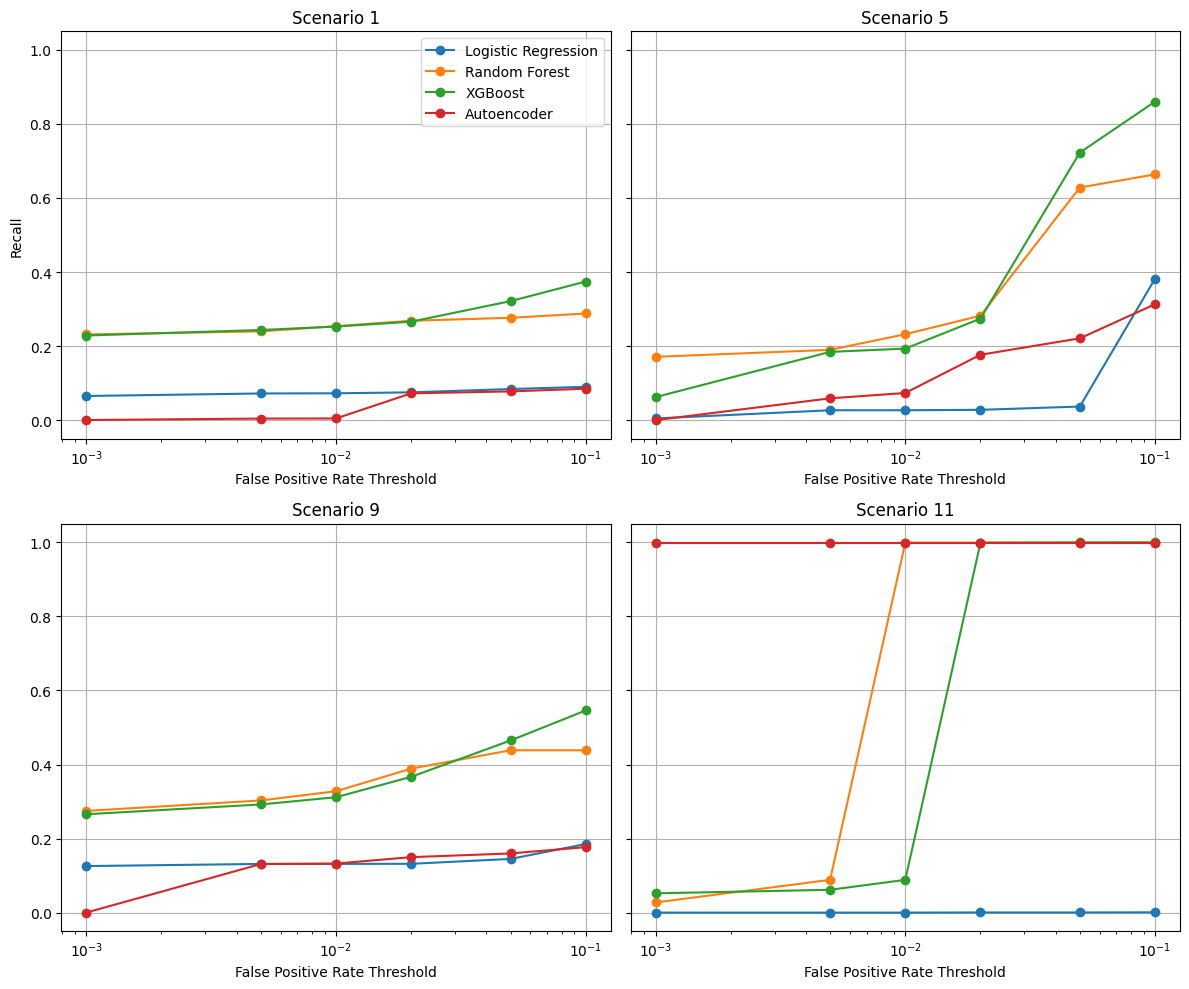

In [10]:
# Test on Scenarios 1, 5, 9, and 11 using the models trained on Scenario 8
evaluate_and_plot_multiple_scenarios(
    scenarios=[
        ("Scenario 1", "capture20110810.binetflow"),
        ("Scenario 5", "capture20110815-2.binetflow"),
        ("Scenario 9", "capture20110817.binetflow"),
        ("Scenario 11", "capture20110818-2.binetflow")
    ],
    X_train=X_train,
    log_model=log_model,
    rf_model=rf_model,
    xgb_model=xgb_model,
    aut_enc_model=enc_model,
    aut_dec_model=dec_model,
    thresholds=[0.001, 0.005, 0.01, 0.02, 0.05, 0.10],
    scaler=scaler,
    DROP_COLUMNS=DROP_COLUMNS,
    device=device
)

## Analysis
It makes sense that Random Forest and Autoencoder do well because it is good at generalization since for RF Each tree looks at independent features and that prevents overfitting, the Autoencoder is not trained on botnet traffic and only detects anomalies. XGBoost features built in L1 and L2 regularization that help generalization as well. 

## 10.1 t-SNE Visualization for Scenario 8

This section uses t-SNE as a qualitative diagnostic to compare how the models separate normal and botnet traffic on Scenario 8 validation data.

We build one shared 2D embedding from the same validation subset, then overlay:
- True labels
- Error maps for Logistic, Random Forest, XGBoost, and Autoencoder
- Confidence/anomaly score maps

Note: t-SNE is for visualization and interpretability, not a replacement for ROC-AUC or recall at fixed FPR.

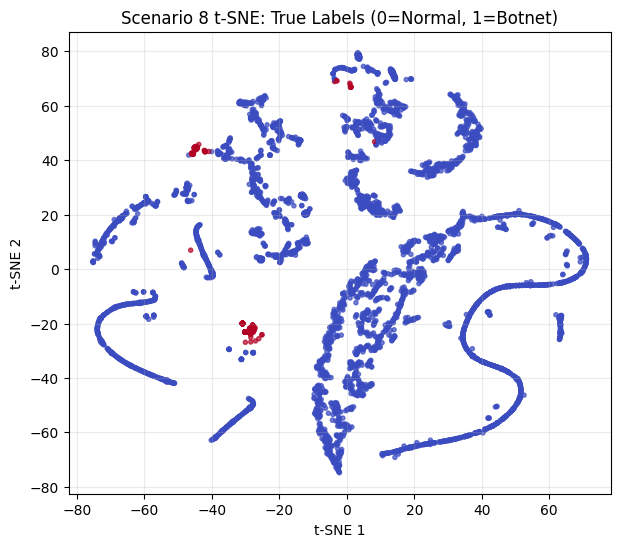

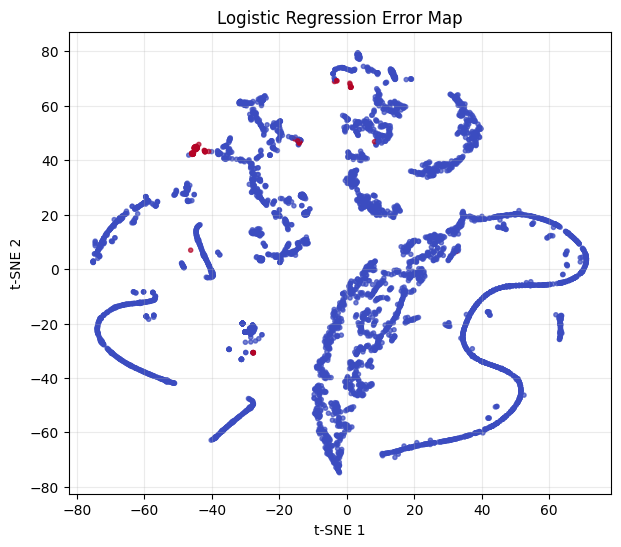

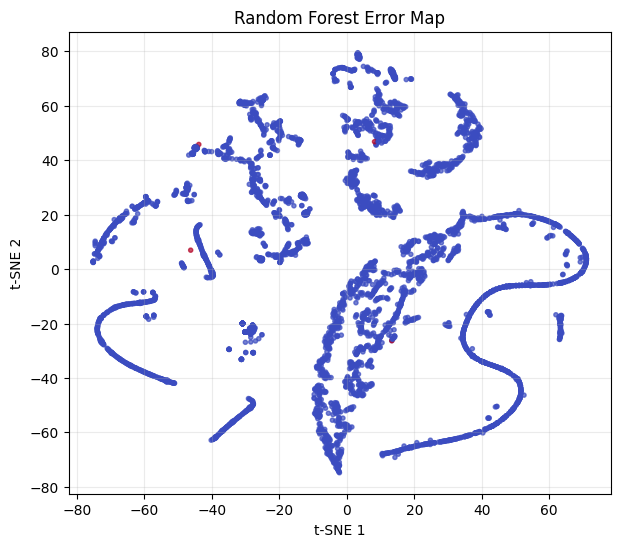

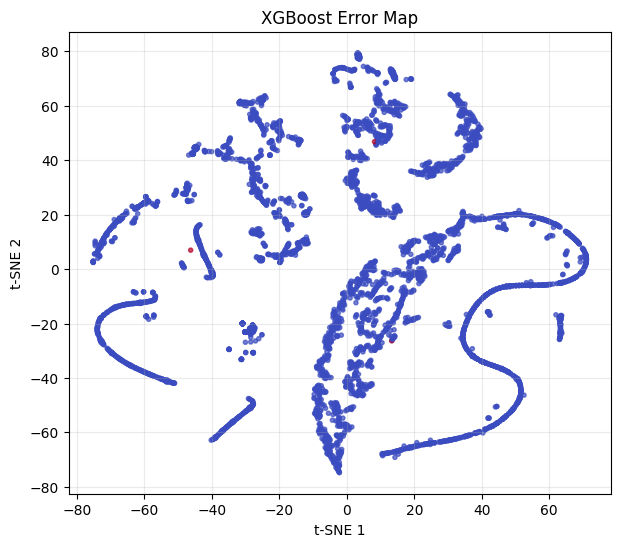

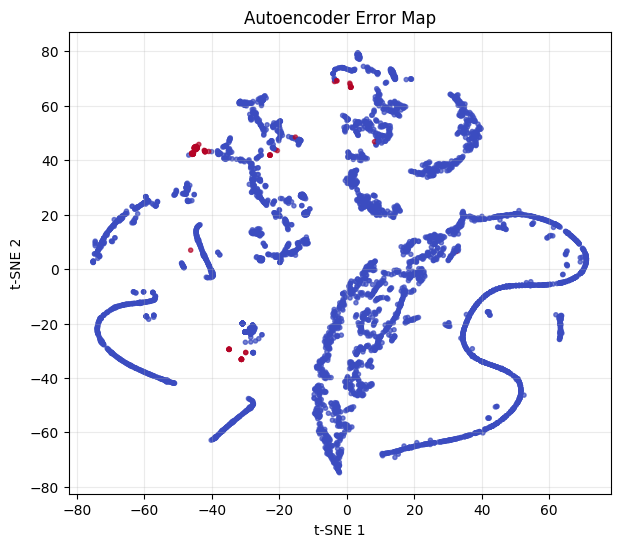

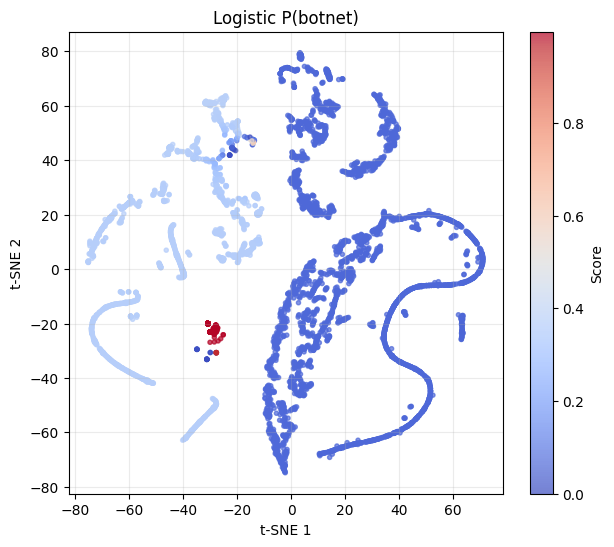

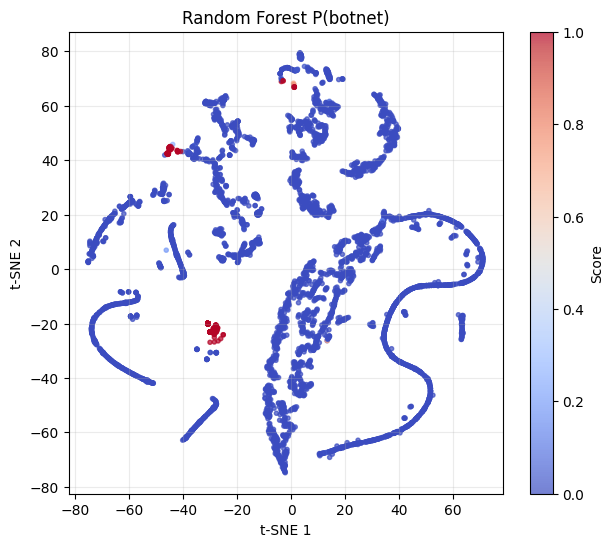

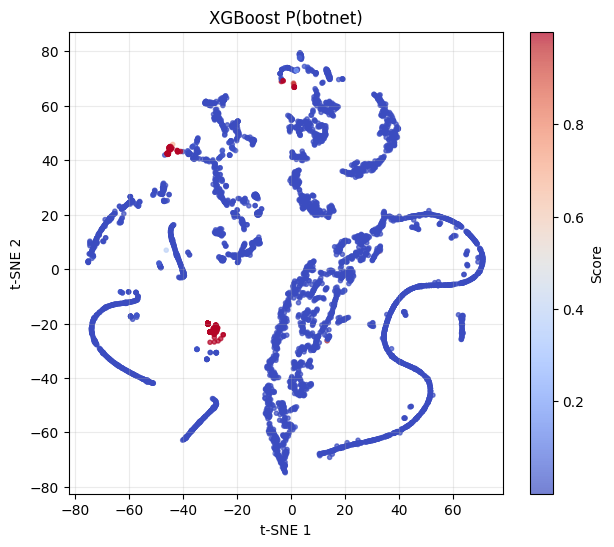

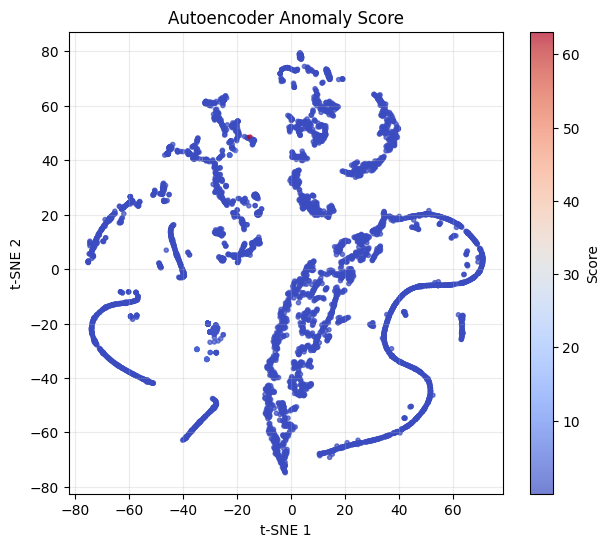

In [14]:
from sklearn.manifold import TSNE

# Subsample for speed and readability (t-SNE can be slow on very large sets)
max_points = 5000
if len(X_test_scaled) > max_points:
    rng = np.random.RandomState(RANDOM_STATE)
    idx = rng.choice(len(X_test_scaled), size=max_points, replace=False)
else:
    idx = np.arange(len(X_test_scaled))

X_vis_scaled = X_test_scaled[idx]
y_vis = y_test.iloc[idx].to_numpy() if hasattr(y_test, "iloc") else np.array(y_test)[idx]
X_vis_unscaled = X_test.iloc[idx] if hasattr(X_test, "iloc") else X_test[idx]

# Shared embedding so all model overlays are directly comparable
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=RANDOM_STATE
)
Z = tsne.fit_transform(X_vis_scaled)

# Model outputs on the same subset
log_probs_vis = log_model.predict_proba(X_vis_scaled)[:, 1]
log_pred_vis = (log_probs_vis >= 0.5).astype(int)

rf_probs_vis = rf_model.predict_proba(X_vis_unscaled)[:, 1]
rf_pred_vis = (rf_probs_vis >= 0.5).astype(int)

xgb_probs_vis = xgb_model.predict_proba(X_vis_unscaled)[:, 1]
xgb_pred_vis = (xgb_probs_vis >= 0.5).astype(int)

with torch.no_grad():
    X_tensor_vis = torch.tensor(X_vis_scaled, dtype=torch.float32, device=device)
    b_vis = enc_model(X_tensor_vis)
    r_vis = dec_model(b_vis)
    ae_scores_vis = torch.mean((r_vis - X_tensor_vis) ** 2, dim=1).cpu().numpy()

ae_pred_vis = (ae_scores_vis >= ae_threshold).astype(int)


def plot_tsne_overlay(embedding, values, title, binary=True, cmap="coolwarm"):
    plt.figure(figsize=(7, 6))
    if binary:
        plt.scatter(embedding[:, 0], embedding[:, 1], c=values, s=9, alpha=0.7, cmap=cmap)
    else:
        sc = plt.scatter(embedding[:, 0], embedding[:, 1], c=values, s=9, alpha=0.7, cmap=cmap)
        plt.colorbar(sc, label="Score")
    plt.title(title)
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.grid(alpha=0.25)
    plt.show()


# 1) Ground-truth structure
plot_tsne_overlay(Z, y_vis, "Scenario 8 t-SNE: True Labels (0=Normal, 1=Botnet)", binary=True)

# 2) Error maps (1 means misclassified)
plot_tsne_overlay(Z, (log_pred_vis != y_vis).astype(int), "Logistic Regression Error Map", binary=True)
plot_tsne_overlay(Z, (rf_pred_vis != y_vis).astype(int), "Random Forest Error Map", binary=True)
plot_tsne_overlay(Z, (xgb_pred_vis != y_vis).astype(int), "XGBoost Error Map", binary=True)
plot_tsne_overlay(Z, (ae_pred_vis != y_vis).astype(int), "Autoencoder Error Map", binary=True)

# 3) Confidence/anomaly score overlays
plot_tsne_overlay(Z, log_probs_vis, "Logistic P(botnet)", binary=False)
plot_tsne_overlay(Z, rf_probs_vis, "Random Forest P(botnet)", binary=False)
plot_tsne_overlay(Z, xgb_probs_vis, "XGBoost P(botnet)", binary=False)
plot_tsne_overlay(Z, ae_scores_vis, "Autoencoder Anomaly Score", binary=False)

## 11. What if we trained on a different dataset?

We can simlilarly write a method that performs the training steps above of a different dataset. This method `train_data` is also provided in the `final_util.py` file of helper functions. Since Scenario 8 only had Port Scan (PS) botnets we can try training on Scenario 4. Then we can test the senario, not only on itself but also cross-scenario evaluate on scenarios 1, 5, 10, and 11.

In [11]:
# Train on Scenario 4 (Neris Botnet: IRC, SPAM, CF, and PS present)
X_train_4, log_model_4, rf_model_4, xgb_model_4, enc_model_4, dec_model_4, scaler_4 = train_data(
    scenario_name="Scenario 4",
    data="capture20110815.binetflow",
    DROP_COLUMNS=DROP_COLUMNS,
    RANDOM_STATE=RANDOM_STATE
)

--- Training on Scenario 4 ---
Training logistic regression classifier started...
Training logistic regression classifier completed. Elapsed time: 0.04s

Training Enhanced Autoencoder started...
Training Enhanced Autoencoder completed. Elapsed time: 10.23s

--- Training on Scenario 4 complete ---



--- Cross-Scenario Performance on Scenario 4 at Various FPR Thresholds ---
FPR Threshold: 0.100% | Logistic Recall: 100.00% | RF Recall: 100.00% | XGB Recall: 100.00% | AE Recall: 0.04%
FPR Threshold: 0.500% | Logistic Recall: 100.00% | RF Recall: 100.00% | XGB Recall: 100.00% | AE Recall: 0.12%
FPR Threshold: 1.000% | Logistic Recall: 100.00% | RF Recall: 100.00% | XGB Recall: 100.00% | AE Recall: 28.06%
FPR Threshold: 2.000% | Logistic Recall: 100.00% | RF Recall: 100.00% | XGB Recall: 100.00% | AE Recall: 68.72%
FPR Threshold: 5.000% | Logistic Recall: 100.00% | RF Recall: 100.00% | XGB Recall: 100.00% | AE Recall: 100.00%
FPR Threshold: 10.000% | Logistic Recall: 100.00% | RF Recall: 100.00% | XGB Recall: 100.00% | AE Recall: 100.00%
--- Summary for Scenario 4 ---
Logistic Regression ROC-AUC: 1.0000
Random Forest ROC-AUC: 1.0000
XGBoost ROC-AUC: 1.0000
Autoencoder ROC-AUC: 0.9814




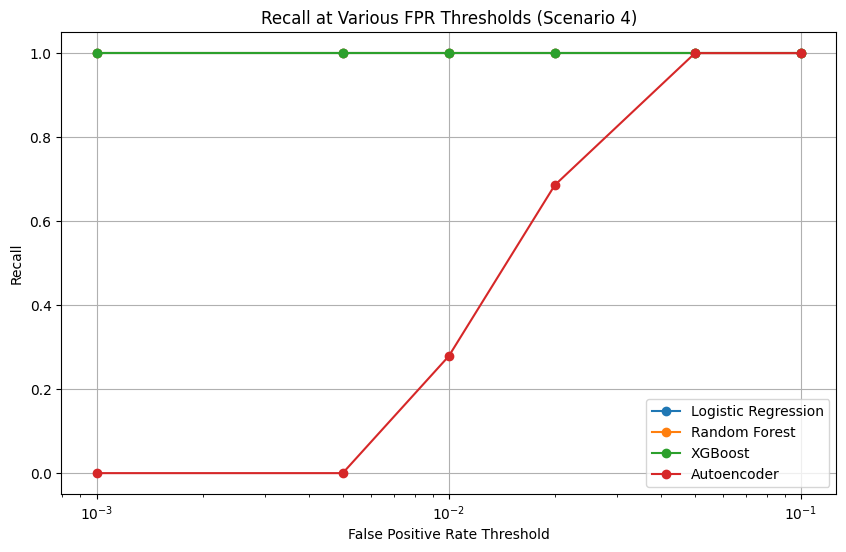

In [12]:
# Test on Scenario 4's 20% validation set and print results
evaluate_model_performance(
    scenario_name="Scenario 4",
    data="capture20110815.binetflow",
    X_train=X_train_4,
    log_model=log_model_4,
    rf_model=rf_model_4,
    xgb_model=xgb_model_4,
    aut_enc_model=enc_model_4,
    aut_dec_model=dec_model_4,
    thresholds=[0.001, 0.005, 0.01, 0.02, 0.05, 0.10],
    scaler=scaler_4,
    DROP_COLUMNS=DROP_COLUMNS,
    device=device
)

## 11.1 t-SNE Visualization for Scenario 4

Similar to Scenario 8, we use t-SNE to visualize how the Scenario 4-trained models separate botnet from normal traffic on the Scenario 4 validation set.

This helps us understand:
- Whether Scenario 4's diverse botnet types (IRC, SPAM, CF, PS) create more complex decision boundaries
- How model errors are distributed across the feature space
- Whether models trained on richer botnet diversity show different behavior patterns

Loading capture20110815.binetflow...
Filtered 1093228 background rows. 27848 rows remaining.
--- Scenario 4 t-SNE Visualizations ---



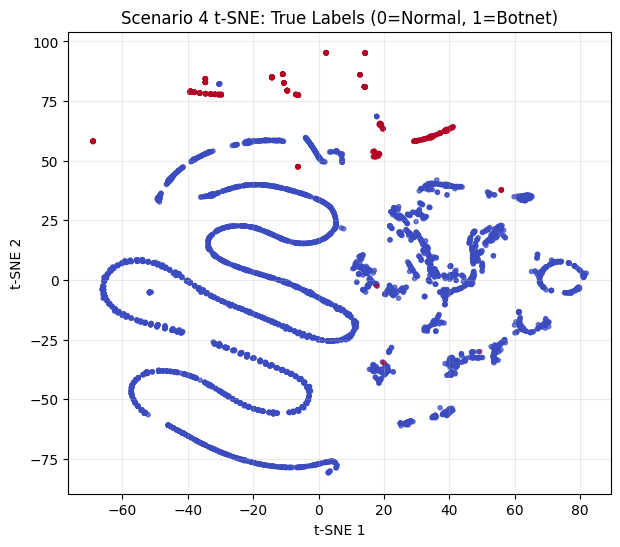

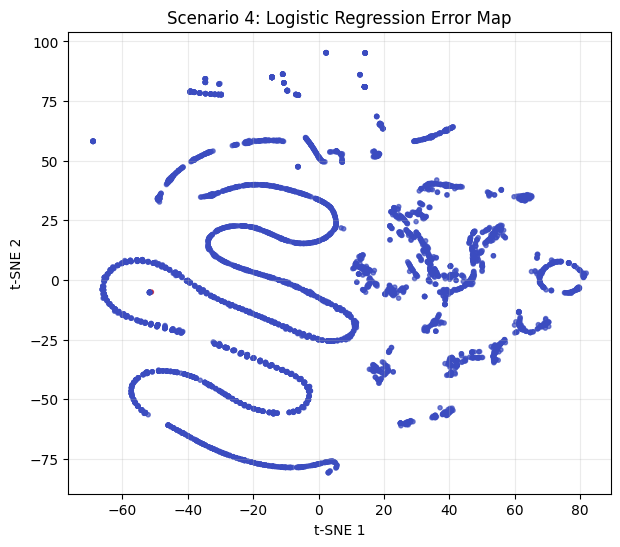

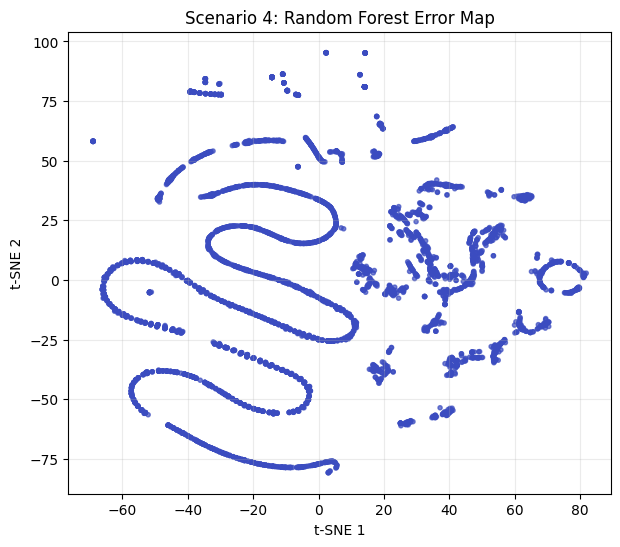

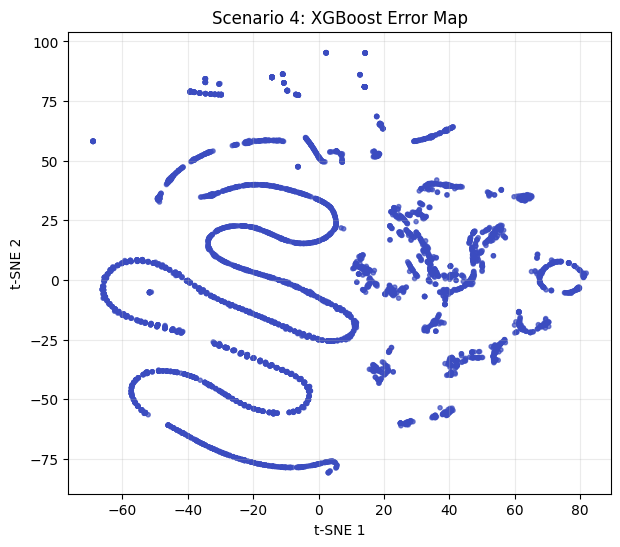

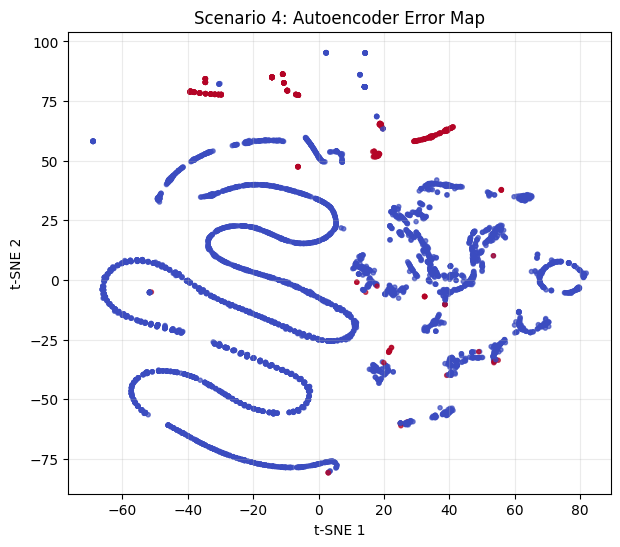

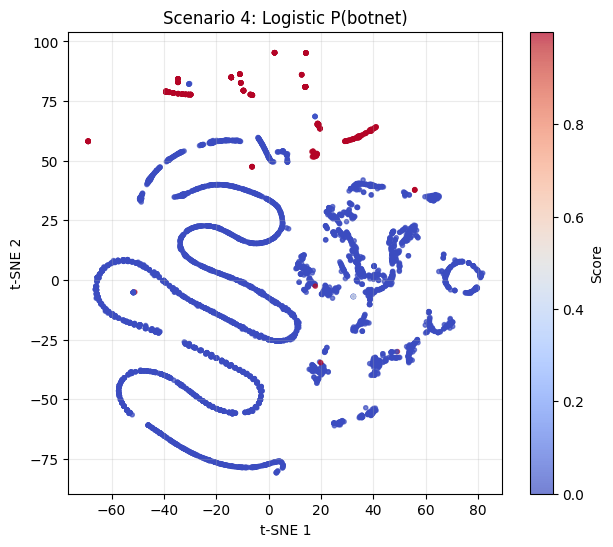

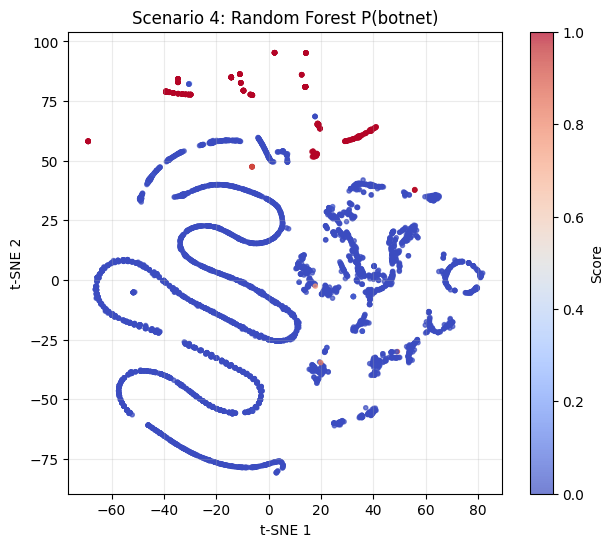

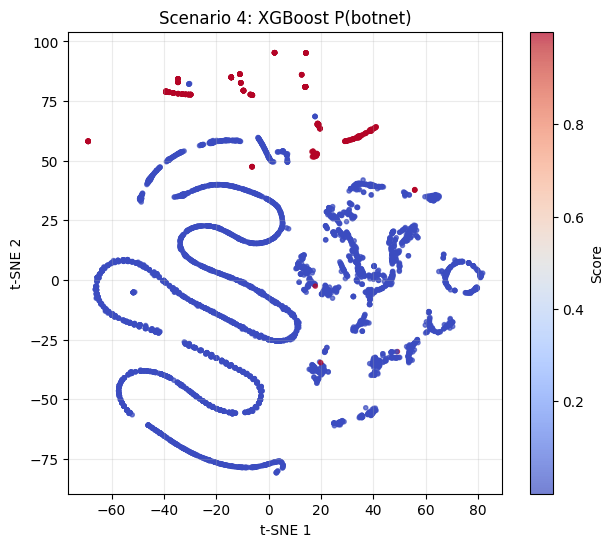

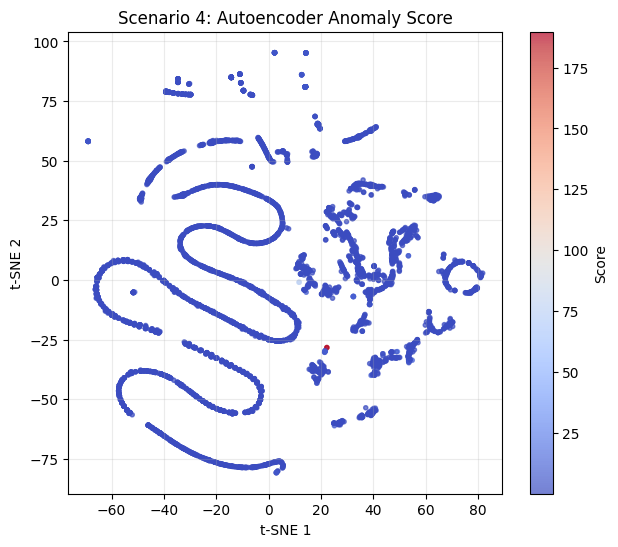

In [15]:
# Load and prepare Scenario 4 validation data for t-SNE
scenario_4_raw = load_and_clean_binetflow("./", "capture20110815.binetflow")
processed_4 = process_labels(scenario_4_raw)
engineered_4 = feature_engineering(processed_4)
X_4, y_4 = prepare_features(engineered_4, DROP_COLUMNS=DROP_COLUMNS)

# Ensure all columns are numeric
X_4 = X_4.apply(pd.to_numeric, errors='coerce').fillna(0)

# Split to get validation set (matching training split)
_, X_test_4, _, y_test_4 = train_test_split(X_4, y_4, test_size=0.2, stratify=y_4, random_state=RANDOM_STATE)

# Handle column alignment and scaling
for col in X_train_4.columns:
    if col not in X_test_4.columns:
        X_test_4[col] = 0
X_test_4 = X_test_4[X_train_4.columns]
X_test_4_scaled = scaler_4.transform(X_test_4)

# Subsample for t-SNE
max_points = 5000
if len(X_test_4_scaled) > max_points:
    rng = np.random.RandomState(RANDOM_STATE)
    idx_4 = rng.choice(len(X_test_4_scaled), size=max_points, replace=False)
else:
    idx_4 = np.arange(len(X_test_4_scaled))

X_vis_4_scaled = X_test_4_scaled[idx_4]
y_vis_4 = y_test_4.iloc[idx_4].to_numpy() if hasattr(y_test_4, "iloc") else np.array(y_test_4)[idx_4]
X_vis_4_unscaled = X_test_4.iloc[idx_4] if hasattr(X_test_4, "iloc") else X_test_4[idx_4]

# Compute t-SNE embedding for Scenario 4
tsne_4 = TSNE(n_components=2, perplexity=30, learning_rate="auto", init="pca", random_state=RANDOM_STATE)
Z_4 = tsne_4.fit_transform(X_vis_4_scaled)

# Get model predictions on Scenario 4 validation subset
log_probs_4_vis = log_model_4.predict_proba(X_vis_4_scaled)[:, 1]
log_pred_4_vis = (log_probs_4_vis >= 0.5).astype(int)

rf_probs_4_vis = rf_model_4.predict_proba(X_vis_4_unscaled)[:, 1]
rf_pred_4_vis = (rf_probs_4_vis >= 0.5).astype(int)

xgb_probs_4_vis = xgb_model_4.predict_proba(X_vis_4_unscaled)[:, 1]
xgb_pred_4_vis = (xgb_probs_4_vis >= 0.5).astype(int)

with torch.no_grad():
    X_tensor_4_vis = torch.tensor(X_vis_4_scaled, dtype=torch.float32, device=device)
    b_4_vis = enc_model_4(X_tensor_4_vis)
    r_4_vis = dec_model_4(b_4_vis)
    ae_scores_4_vis = torch.mean((r_4_vis - X_tensor_4_vis) ** 2, dim=1).cpu().numpy()

# Get ae_threshold for Scenario 4 (compute from full validation set)
with torch.no_grad():
    X_test_4_tensor = torch.tensor(X_test_4_scaled, dtype=torch.float32, device=device)
    b_test_4 = enc_model_4(X_test_4_tensor)
    r_test_4 = dec_model_4(b_test_4)
    mse_scores_4 = torch.mean((r_test_4 - X_test_4_tensor)**2, dim=1).cpu().numpy()
ae_threshold_4 = select_threshold_at_fpr(y_test_4, mse_scores_4, target_fpr=0.01)

ae_pred_4_vis = (ae_scores_4_vis >= ae_threshold_4).astype(int)

# Plot t-SNE results for Scenario 4
print("--- Scenario 4 t-SNE Visualizations ---\n")

# 1) Ground-truth structure
plot_tsne_overlay(Z_4, y_vis_4, "Scenario 4 t-SNE: True Labels (0=Normal, 1=Botnet)", binary=True)

# 2) Error maps
plot_tsne_overlay(Z_4, (log_pred_4_vis != y_vis_4).astype(int), "Scenario 4: Logistic Regression Error Map", binary=True)
plot_tsne_overlay(Z_4, (rf_pred_4_vis != y_vis_4).astype(int), "Scenario 4: Random Forest Error Map", binary=True)
plot_tsne_overlay(Z_4, (xgb_pred_4_vis != y_vis_4).astype(int), "Scenario 4: XGBoost Error Map", binary=True)
plot_tsne_overlay(Z_4, (ae_pred_4_vis != y_vis_4).astype(int), "Scenario 4: Autoencoder Error Map", binary=True)

# 3) Confidence/anomaly score overlays
plot_tsne_overlay(Z_4, log_probs_4_vis, "Scenario 4: Logistic P(botnet)", binary=False)
plot_tsne_overlay(Z_4, rf_probs_4_vis, "Scenario 4: Random Forest P(botnet)", binary=False)
plot_tsne_overlay(Z_4, xgb_probs_4_vis, "Scenario 4: XGBoost P(botnet)", binary=False)
plot_tsne_overlay(Z_4, ae_scores_4_vis, "Scenario 4: Autoencoder Anomaly Score", binary=False)

--- Cross-Scenario Performance on Scenario 1 at Various FPR Thresholds ---
FPR Threshold: 0.100% | Logistic Recall: 99.86% | RF Recall: 100.00% | XGB Recall: 100.00% | AE Recall: 0.13%
FPR Threshold: 0.500% | Logistic Recall: 99.86% | RF Recall: 100.00% | XGB Recall: 100.00% | AE Recall: 0.19%
FPR Threshold: 1.000% | Logistic Recall: 99.86% | RF Recall: 100.00% | XGB Recall: 100.00% | AE Recall: 0.39%
FPR Threshold: 2.000% | Logistic Recall: 99.87% | RF Recall: 100.00% | XGB Recall: 100.00% | AE Recall: 8.96%
FPR Threshold: 5.000% | Logistic Recall: 99.87% | RF Recall: 100.00% | XGB Recall: 100.00% | AE Recall: 100.00%
FPR Threshold: 10.000% | Logistic Recall: 99.87% | RF Recall: 100.00% | XGB Recall: 100.00% | AE Recall: 100.00%
--- Summary for Scenario 1 ---
Logistic Regression ROC-AUC: 0.9986
Random Forest ROC-AUC: 0.9999
XGBoost ROC-AUC: 1.0000
Autoencoder ROC-AUC: 0.9716


--- Cross-Scenario Performance on Scenario 5 at Various FPR Thresholds ---
FPR Threshold: 0.100% | Logistic R

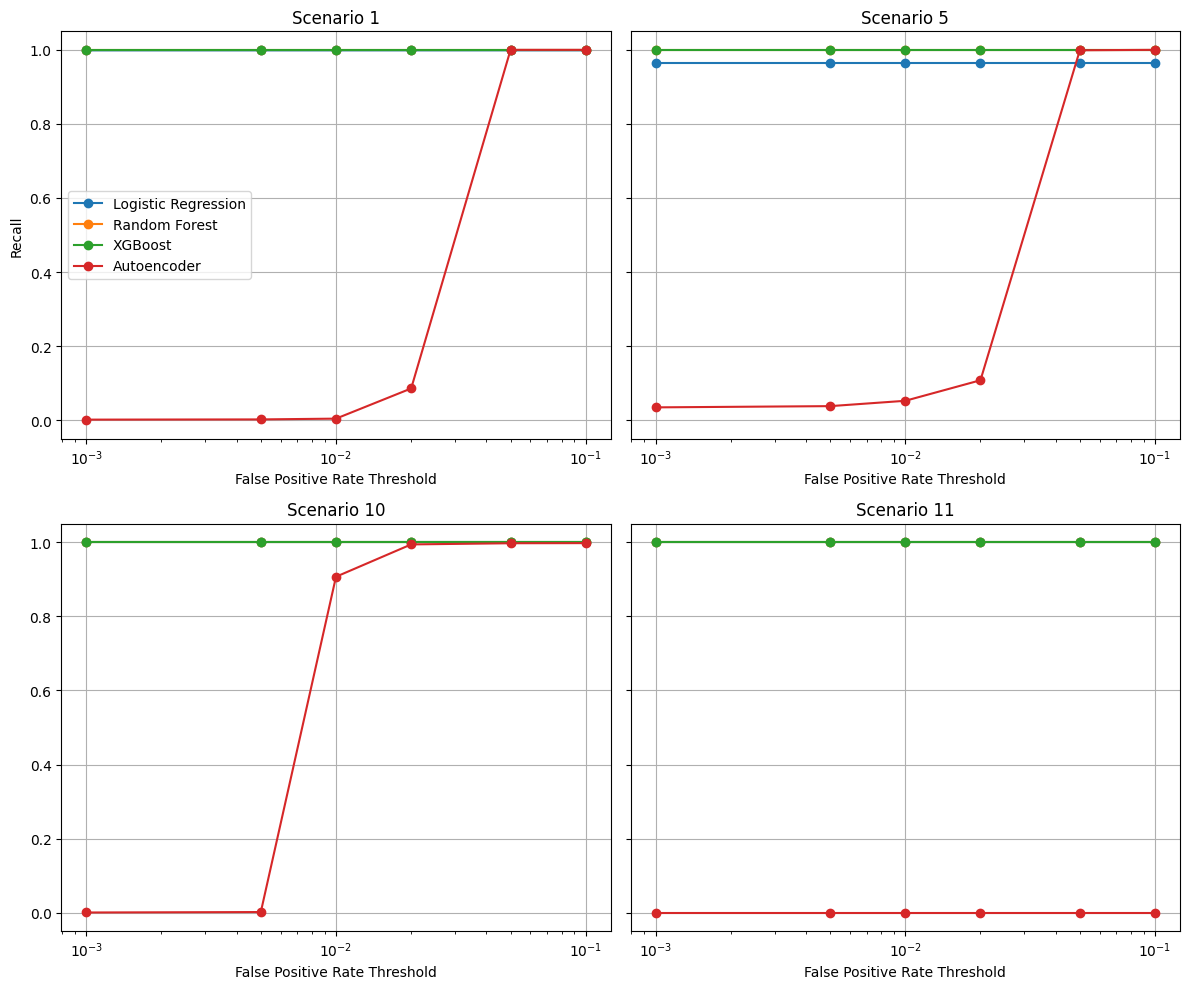

In [13]:
# Test on Scenarios 1, 5, 10, and 11 using the models trained on Scenario 4
evaluate_and_plot_multiple_scenarios(
    scenarios=[
        ("Scenario 1", "capture20110810.binetflow"),
        ("Scenario 5", "capture20110815-2.binetflow"),
        ("Scenario 10", "capture20110818.binetflow"),
        ("Scenario 11", "capture20110818-2.binetflow")
    ],
    X_train=X_train_4,
    log_model=log_model_4,
    rf_model=rf_model_4,
    xgb_model=xgb_model_4,
    aut_enc_model=enc_model_4,
    aut_dec_model=dec_model_4,
    thresholds=[0.001, 0.005, 0.01, 0.02, 0.05, 0.10],
    scaler=scaler_4,
    DROP_COLUMNS=DROP_COLUMNS,
    device=device
)